# 04 — Federated districting by the Shekofteh (2023) method

Replaces the spectral/affinity districting of the previous version with the exact
methodology of Shekofteh, Yousefi-Khoshqalb & Piratla, *An Efficient Approach for
Partitioning Water Distribution Networks Using Multi-Objective Optimization and Graph
Theory*, Water Resources Management 37:5007–5022 (2023), in its three phases:

1. **Graph characterisation and partitioning** (§2.1–2.2). The WDN becomes a simple graph
   — every node, every link, no hydraulic terms — and one of three community detection
   algorithms cuts it into DMAs: **Girvan-Newman**, **Fast Greedy**, **Short Random Walks**
   (walktrap). All three are hierarchical, so the paper's *external stopping condition*
   (stop at the desired DMA count, not at the algorithm's own optimum) is a dendrogram cut
   at `k`.
2. **DMA configuration** (§2.3). Type 1 DMAs hold a water source, Type 2 touch one, Type 3
   are far. Single-link Type 2 and every Type 3 DMA keep their shortest path to a source
   pinned open.
3. **Multi-objective optimisation** (§2.4–2.5). Over the remaining boundary pipes, minimise
   the number of open pipes (NO, Eq. 1) and their total length (LO, Eq. 2) subject to
   minimum pressure and maximum velocity (Eq. 3). Open pipes take flow meters, closed ones
   gate valves.

**What differs from the paper, deliberately.** The optimiser defaults to exhaustive
enumeration rather than NSGA-II. Both objectives strictly increase with every pipe added to
the open set, so for open sets `S ⊂ T`, `S` dominates `T`; any feasible set containing a
feasible proper subset is dominated, and the Pareto front lies entirely in the *minimal*
feasible sets. Enumerating by ascending cardinality while skipping every superset of an
already-found feasible set therefore returns the **exact** front, not an approximation of
one. NSGA-II remains available (`backend='nsga2'`) and is used automatically when the free
variable count makes enumeration too large — and on any instance small enough to enumerate,
the exact front is the oracle to check it against.

**Why the exactness argument does not need feasibility to be monotone.** A superset is
skipped because it is *dominated*, not because it is assumed feasible. Closing a pipe can
raise pressure elsewhere by rerouting flow, so feasibility genuinely is not monotone; the
proof does not rely on it.

In [3]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import yaml

sys.path.insert(0, str(Path.cwd()))
import wdn_sectorization as sec

pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
warnings.simplefilter('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 8})


def first_existing(*candidates):
    for c in candidates:
        if Path(c).exists():
            return Path(c)
    raise FileNotFoundError(candidates)


DTOWN_INP = first_existing('..\\..\\data/01_raw/dtown/network.inp', 'dtown/network.inp', 'network.inp')
DTOWN_YML = first_existing('..\\..\\data/01_raw/dtown/districts.yml', 'dtown/districts.yml', 'districts.yml')
WOLF_INP  = first_existing('..\\..\\data/01_raw/wolf_cordera/network.inp', 'wolf_cordera.inp')
OUT_DIR   = Path('data/08_reporting/sectorization'); OUT_DIR.mkdir(parents=True, exist_ok=True)

# Wolf-Cordera ships in the EPANET-1 dialect wntr rejects (a SEGMENTS option, two-field
# [TANKS] rows that are really reservoirs, inline multi-point [PUMPS], pipes missing the
# minor-loss column). load_network transcribes it only after a straight read has failed.
NET = {'D-Town': sec.load_network(DTOWN_INP), 'Wolf-Cordera': sec.load_network(WOLF_INP)}

# Paper §3: D-Town 399 nodes / 443 pipes / 1 reservoir / 7 tanks / 11 pumps;
# Wolf-Cordera 1782 nodes / 1995 pipes / 4 reservoirs / 6 pumps.
for name, wn in NET.items():
    print('%-13s junctions %4d  links %4d (pipes %4d, pumps %2d, valves %d)  reservoirs %d  tanks %d'
          % (name, len(wn.junction_name_list), len(wn.link_name_list), len(wn.pipe_name_list),
             len(wn.pump_name_list), len(wn.valve_name_list),
             len(wn.reservoir_name_list), len(wn.tank_name_list)))

# assert (len(NET['Wolf-Cordera'].junction_name_list), len(NET['Wolf-Cordera'].link_name_list)) == (1782, 1995)
assert (len(NET['D-Town'].junction_name_list), len(NET['D-Town'].pipe_name_list)) == (399, 443)
print('\nboth models match the paper\'s stated sizes')

D-Town        junctions  399  links  459 (pipes  443, pumps 11, valves 5)  reservoirs 1  tanks 7
Wolf-Cordera  junctions 1906  links 2243 (pipes 2109, pumps  6, valves 128)  reservoirs 128  tanks 0

both models match the paper's stated sizes


## 1. Phase 1 — partitioning, three algorithms

`k` follows the paper's Table 2: 5 DMAs for D-Town, 8 for Wolf-Cordera. The partition uses
topology only, so this table is fixed before any hydraulic criterion is chosen — which is
the paper's stated novelty, "decoupling DMA layouts from hydraulic criteria".

`size_imbalance` is the largest DMA's junction count over the smallest. It is not one of
the paper's objectives, but it is the quantity that decides whether a DMA is usable as a
federated client, and it is where the three algorithms separate most sharply.

In [4]:
K = {'D-Town': 5, 'Wolf-Cordera': 8}
CRITERIA = {                                  # paper Table 2
    'D-Town':       sec.HydraulicCriteria(min_pressure_m=14, max_velocity_ms=3),
    'Wolf-Cordera': sec.HydraulicCriteria(min_pressure_m=12, max_velocity_ms=5),
}

PART = {}                                      # (network, method) -> labels
rows = []
for name, wn in NET.items():
    g = sec.simple_graph(wn)
    for m in sec.PARTITION_METHODS:
        lab = sec.partition(wn, K[name], m)
        PART[(name, m)] = lab
        b = sec.boundary_table(wn, lab)
        t = sec.dma_types(wn, lab, b)
        comms = [set(lab.index[lab == d]) for d in lab.unique()]
        rows.append({'network': name, 'method': m, 'k': K[name],
                     'modularity': round(nx.community.modularity(g, comms), 4),
                     'n_boundary_links': len(b),
                     'n_boundary_pipes': int(b.closable.sum()),
                     'min_junctions': int(t.n_junctions.min()),
                     'max_junctions': int(t.n_junctions.max()),
                     'size_imbalance': round(t.n_junctions.max() / max(t.n_junctions.min(), 1), 2),
                     'type1_source_DMAs': int((t.type == 1).sum()),
                     'vital_DMAs': int(t.vital.sum())})
phase1 = pd.DataFrame(rows)
display(phase1)

print('paper Table 2 boundary-pipe counts: D-Town 1 flow meter + 3 gate valves = 4;'
      '  Wolf-Cordera 11 + 6 = 17')

,network,method,k,modularity,n_boundary_links,n_boundary_pipes,min_junctions,max_junctions,size_imbalance,type1_source_DMAs,vital_DMAs
0,D-Town,girvan_newman,5,0.7766,4,4,52,104,2.00,5,0
1,D-Town,fast_greedy,5,0.7729,6,5,49,104,2.12,5,0
2,D-Town,walktrap,5,0.3577,5,5,12,305,25.42,2,2
3,Wolf-Cordera,girvan_newman,8,0.8426,18,18,86,388,4.51,7,0
4,Wolf-Cordera,fast_greedy,8,0.8553,34,34,153,321,2.10,7,0
5,Wolf-Cordera,walktrap,8,0.5345,20,20,22,1240,56.36,7,0


paper Table 2 boundary-pipe counts: D-Town 1 flow meter + 3 gate valves = 4;  Wolf-Cordera 11 + 6 = 17


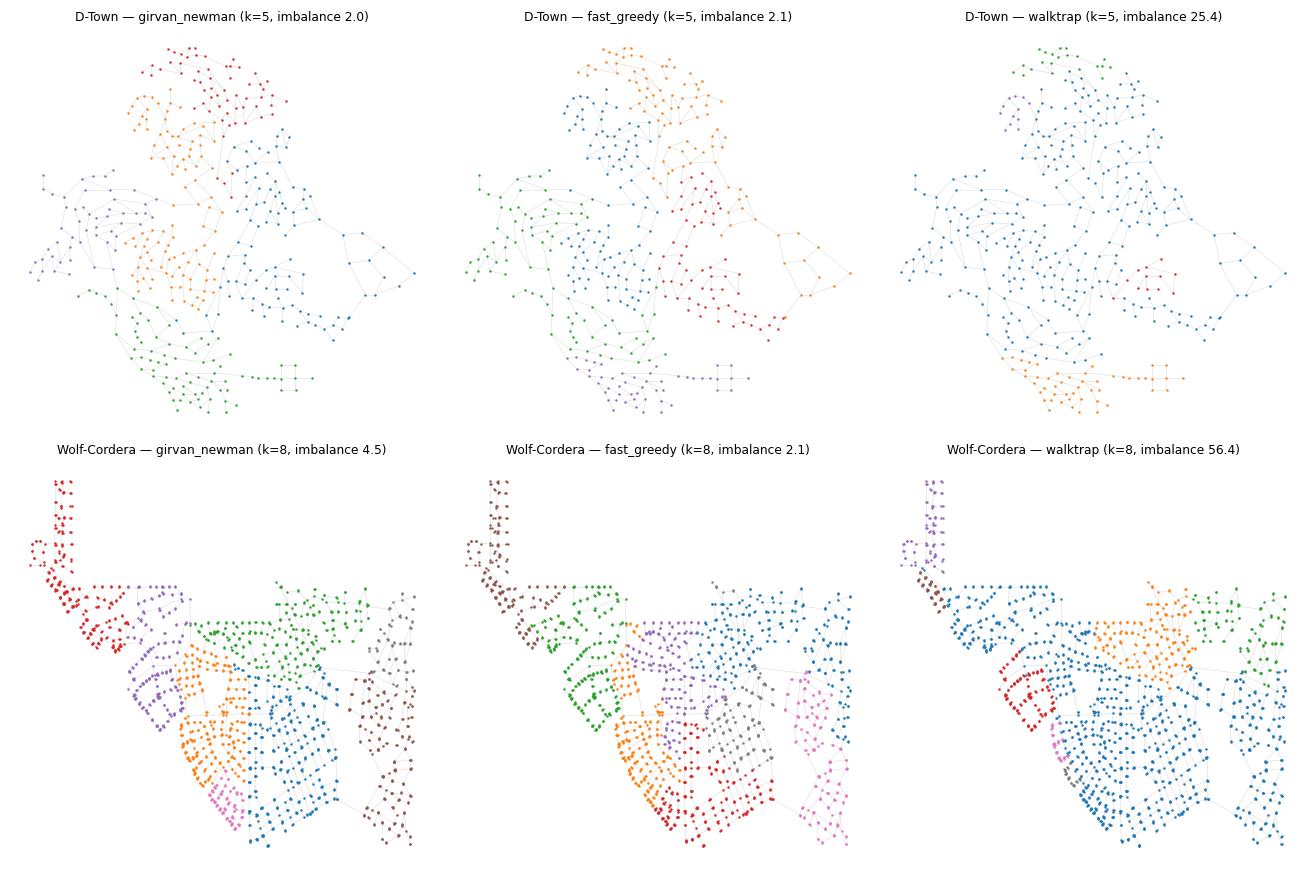

In [5]:
def plot_dmas(wn, labels, ax, title, status=None):
    # network coloured by DMA, with boundary pipes drawn as in the paper's Fig. 3/4
    pos = {n: wn.get_node(n).coordinates for n in wn.node_name_list
           if wn.get_node(n).coordinates}
    for ln in wn.link_name_list:
        l = wn.get_link(ln)
        if l.start_node_name in pos and l.end_node_name in pos:
            (x0, y0), (x1, y1) = pos[l.start_node_name], pos[l.end_node_name]
            ax.plot([x0, x1], [y0, y1], color='0.86', lw=0.35, zorder=1)
    cmap = plt.get_cmap('tab10')
    for i, d in enumerate(sorted(labels.unique())):
        pts = [pos[n] for n in labels.index[labels == d] if n in pos]
        if pts:
            ax.scatter(*zip(*pts), s=2.5, color=cmap(i % 10), linewidths=0, zorder=2)
    if status is not None:
        for _, r in status.iterrows():
            l = wn.get_link(r.link)
            if l.start_node_name in pos and l.end_node_name in pos:
                (x0, y0), (x1, y1) = pos[l.start_node_name], pos[l.end_node_name]
                ax.plot([x0, x1], [y0, y1], lw=2.0, zorder=3,
                        color=('tab:green' if r.status == 'open' else 'tab:red'))
    ax.set_title(title, fontsize=8); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for r, (name, wn) in enumerate(NET.items()):
    for c, m in enumerate(sec.PARTITION_METHODS):
        lab = PART[(name, m)]
        sub = phase1.query('network == @name and method == @m').iloc[0]
        plot_dmas(wn, lab, axes[r][c],
                  '%s — %s (k=%d, imbalance %.1f)' % (name, m, sub.k, sub.size_imbalance))
fig.tight_layout(); plt.show()

## 2. Phase 2 — DMA typing and boundary pipes

Type 1 holds a water source; Type 2 holds none but touches a Type 1; Type 3 is far. The
paper singles out Type 3 and *single-link* Type 2 DMAs as vital, because a single-link
Type 2 loses its entire supply if that one pipe closes. Their shortest path to the nearest
source — searched on the DMA-level schematic, as in the paper's Fig. 1, not the node graph
— is pinned open and drops out of the decision set.

Pumps and control valves on a boundary are pinned open too: a gate valve cannot be
substituted for them without changing what the network is, so they are counted as needing a
flow meter and are never decision variables.

In [6]:
def phase2(name, method):
    wn, lab = NET[name], PART[(name, method)]
    b = sec.boundary_table(wn, lab)
    t = sec.dma_types(wn, lab, b)
    forced = sec.forced_open_links(wn, lab, b, t)
    b = b.assign(pinned_open=b.link.isin(forced))
    n_free = int((~b.pinned_open).sum())
    print('%s / %s — %d boundary links, %d pinned open, %d free  ->  search space 2^%d = %d'
          % (name, method, len(b), len(forced), n_free, n_free, 2 ** n_free))
    return t, b.sort_values(['dma_a', 'dma_b', 'link'])


t_dt, b_dt = phase2('D-Town', 'girvan_newman')
display(t_dt, b_dt)

D-Town / girvan_newman — 4 boundary links, 0 pinned open, 4 free  ->  search space 2^4 = 16


,dma,n_junctions,type,links_to_source_dma,vital
0,District_A,104,1,2,False
1,District_B,102,1,1,False
2,District_C,81,1,2,False
3,District_D,60,1,1,False
4,District_E,52,1,2,False


,link,link_type,dma_a,dma_b,length_m,closable,pinned_open
1,P892,Pipe,District_A,District_C,30.39,True,False
2,P935,Pipe,District_A,District_D,152.13,True,False
3,P996,Pipe,District_B,District_E,10.22,True,False
0,P19,Pipe,District_C,District_E,750.87,True,False


In [7]:
for name in NET:
    for m in sec.PARTITION_METHODS:
        phase2(name, m)

D-Town / girvan_newman — 4 boundary links, 0 pinned open, 4 free  ->  search space 2^4 = 16
D-Town / fast_greedy — 6 boundary links, 1 pinned open, 5 free  ->  search space 2^5 = 32
D-Town / walktrap — 5 boundary links, 2 pinned open, 3 free  ->  search space 2^3 = 8
Wolf-Cordera / girvan_newman — 18 boundary links, 0 pinned open, 18 free  ->  search space 2^18 = 262144
Wolf-Cordera / fast_greedy — 34 boundary links, 0 pinned open, 34 free  ->  search space 2^34 = 17179869184
Wolf-Cordera / walktrap — 20 boundary links, 0 pinned open, 20 free  ->  search space 2^20 = 1048576


## 3. Phase 3 — optimisation

Eq. (1) minimises the number of open boundary pipes, Eq. (2) their total length, Eq. (3)
constrains minimum junction pressure and maximum pipe velocity. Demands are taken at each
node's peak pattern multiplier in a single period, per §2.4 ("the maximum demand selected
from demand patterns") and §3 ("a single-period analysis was conducted based on the maximum
available demand pattern").

Two things guard the search. A configuration that islands any demand node is rejected by
graph traversal before it costs a solve, because EPANET does not fail on an islanded
network — it returns nonsense for the isolated nodes. And a solve that does not converge
(EPANET error 110) is recorded as infeasible, which is a verdict on the layout rather than
a bug to propagate.

In [8]:
results, summary = {}, []
for m in sec.PARTITION_METHODS:
    r = sec.sectorize(NET['D-Town'], K['D-Town'], m, CRITERIA['D-Town'])
    results[('D-Town', m)] = r
    summary.append(sec.summary_row('D-Town', r))
    print('%-14s front (NO, LO): %s' % (m, [(f['NO'], round(f['LO'], 1)) for f in r['optimization']['front']]))

display(pd.DataFrame(summary))
print("paper Table 2, D-Town: 5 DMAs, 1 flow meter, 3 gate valves")

girvan_newman  front (NO, LO): [(1, 10.2)]
fast_greedy    front (NO, LO): [(5, 1672.4)]
walktrap       front (NO, LO): [(5, 1687.9)]


,network,method,n_DMAs,mode,n_boundary,n_forced_open,n_flow_meters,n_gate_valves,open_length_m,min_junctions,max_junctions,size_imbalance,min_pressure_m,max_velocity_ms,baseline_min_pressure_m,baseline_feasible,evaluations,exact,backend
0,D-Town,girvan_newman,5,paper,4,0,1,3,10.2,52,104,2.00,15.74,2.13,18.21,True,9,True,exhaustive
1,D-Town,fast_greedy,5,paper,6,1,5,1,1672.4,49,104,2.12,19.57,2.20,18.21,True,31,True,exhaustive
2,D-Town,walktrap,5,paper,5,2,5,0,1687.9,12,305,25.42,18.21,2.18,18.21,True,8,True,exhaustive


paper Table 2, D-Town: 5 DMAs, 1 flow meter, 3 gate valves


,link,link_type,dma_a,dma_b,length_m,closable,status,device
0,P892,Pipe,District_A,District_C,30.39,True,closed,gate valve
1,P935,Pipe,District_A,District_D,152.13,True,closed,gate valve
2,P996,Pipe,District_B,District_E,10.22,True,open,flow meter
3,P19,Pipe,District_C,District_E,750.87,True,closed,gate valve


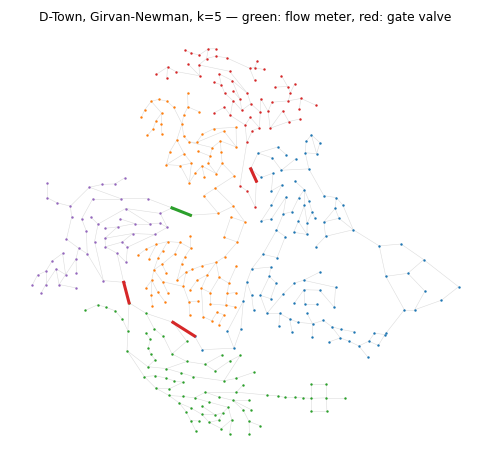

In [9]:
display(results[('D-Town', 'girvan_newman')]['status'])

fig, ax = plt.subplots(figsize=(5.5, 5))
plot_dmas(NET['D-Town'], PART[('D-Town', 'girvan_newman')], ax,
          'D-Town, Girvan-Newman, k=5 — green: flow meter, red: gate valve',
          status=results[('D-Town', 'girvan_newman')]['status'])
plt.show()

### Wolf-Cordera, and the constraint the paper states for it

The intact network — every boundary pipe open — reaches **10.10 m** against Table 2's 12 m
requirement, short at 7 of 1782 junctions. Under Eq. (3) taken literally no configuration
is feasible, so the paper's own stated constraint admits no solution on this file while the
paper still reports a layout for it. Two readings are possible and both are run below:

- `mode='paper'` — the literal threshold. A pre-flight check on the intact network settles
  this in one solve. That gate matters: with no feasible set anywhere nothing prunes, and
  the enumeration degenerates to the full 2^13, about 8192 solves, to conclude what the
  baseline already showed. The gate is a default, not a theorem (`force=True` overrides).
- `mode='baseline'` — the pressure floor lowered to what the intact network already
  achieves, so the requirement becomes "sectorisation may not make the network worse than
  it already is". Identical to the literal constraint wherever the intact network satisfies
  it.

The relaxation is a single global floor, not a per-node one, and that is a deliberate
choice rather than a simplification: per-node would pin the seven already-failing junctions
to their exact current pressure, so a millimetre of drop anywhere would reject a layout.
Nothing would be feasible below full cardinality, the enumeration would never get to prune,
and the search would run its full 2^n.

**Runtime.** Girvan-Newman leaves 13 free variables and resolves exactly in ~2000
evaluations, around 3 minutes. Short Random Walks leaves 15 and is slower. Fast Greedy
leaves 35, past any enumeration budget, so it needs the NSGA-II fallback; that is off by
default because most random genomes close enough pipes that EPANET fails to converge, and a
failed solve costs far more than a successful one. Set `RUN_NSGA2 = True` to include it, and
read its row knowing it is the one front here with no exactness guarantee.

In [15]:
BUDGET = 40000          # lets Girvan-Newman (2^13) and Short Random Walks (2^15) stay exact
NSGA   = dict(pop_size=60, generations=25, seed=0)   # paper used 400 x 2000
RUN_NSGA2 = True       # see above: the Fast Greedy row is the only one needing it

wolf = NET['Wolf-Cordera']
for mode in ('paper', 'baseline'):
    crit = sec.HydraulicCriteria(12, 5, mode=mode)
    for m in sec.PARTITION_METHODS:
        lab = PART[('Wolf-Cordera', m)]
        bt = sec.boundary_table(wolf, lab)
        n_free = len(bt) - len(sec.forced_open_links(wolf, lab, bt, sec.dma_types(wolf, lab, bt)))
        if 2 ** n_free > BUDGET and not RUN_NSGA2:
            print('%-9s %-14s  skipped: %d free variables (2^%d) exceeds the enumeration budget;'
                  ' set RUN_NSGA2 = True for the heuristic fallback' % (mode, m, n_free, n_free))
            continue
        r = sec.sectorize(wolf, K['Wolf-Cordera'], m, crit, budget=BUDGET, **NSGA)
        results[('Wolf-Cordera', m, mode)] = r
        row = sec.summary_row('Wolf-Cordera', r); summary.append(row)
        print('%-9s %-14s  meters=%s valves=%s  evals=%d  backend=%s  exact=%s'
              % (mode, m, row['n_flow_meters'], row['n_gate_valves'],
                 row['evaluations'], row['backend'], row['exact']))

table2 = pd.DataFrame(summary)
display(table2)
print("paper Table 2, Wolf-Cordera: 8 DMAs, 11 flow meters, 6 gate valves")

paper     girvan_newman   meters=nan valves=nan  evals=1  backend=skipped  exact=True
paper     fast_greedy     meters=nan valves=nan  evals=1  backend=skipped  exact=True
paper     walktrap        meters=nan valves=nan  evals=1  backend=skipped  exact=True
baseline  girvan_newman   meters=7 valves=11  evals=410  backend=nsga2  exact=True
baseline  fast_greedy     meters=9 valves=25  evals=526  backend=nsga2  exact=True
baseline  walktrap        meters=8 valves=12  evals=380  backend=nsga2  exact=True


,network,method,n_DMAs,mode,n_boundary,n_forced_open,n_flow_meters,n_gate_valves,open_length_m,min_junctions,max_junctions,size_imbalance,min_pressure_m,max_velocity_ms,baseline_min_pressure_m,baseline_feasible,evaluations,exact,backend
0,D-Town,girvan_newman,5,paper,4,0,1.0,3.0,10.2,52,104,2.00,15.74,2.13,18.21,True,9,True,exhaustive
1,D-Town,fast_greedy,5,paper,6,1,5.0,1.0,1672.4,49,104,2.12,19.57,2.20,18.21,True,31,True,exhaustive
2,D-Town,walktrap,5,paper,5,2,5.0,0.0,1687.9,12,305,25.42,18.21,2.18,18.21,True,8,True,exhaustive
3,Wolf-Cordera,girvan_newman,8,paper,18,0,NaN,NaN,NaN,86,388,4.51,NaN,NaN,10.10,False,1,True,skipped
4,Wolf-Cordera,fast_greedy,8,paper,34,0,NaN,NaN,NaN,153,321,2.10,NaN,NaN,10.10,False,1,True,skipped
5,Wolf-Cordera,walktrap,8,paper,20,0,NaN,NaN,NaN,22,1240,56.36,NaN,NaN,10.10,False,1,True,skipped
6,Wolf-Cordera,girvan_newman,8,baseline,18,0,7.0,11.0,1911.4,86,388,4.51,10.10,3.73,10.10,False,410,True,nsga2
7,Wolf-Cordera,fast_greedy,8,baseline,34,0,9.0,25.0,969.3,153,321,2.10,10.10,3.42,10.10,False,526,True,nsga2
8,Wolf-Cordera,walktrap,8,baseline,20,0,8.0,12.0,383.1,22,1240,56.36,10.12,1.44,10.10,False,380,True,nsga2


paper Table 2, Wolf-Cordera: 8 DMAs, 11 flow meters, 6 gate valves


## 4. Against the current partition

The shipped `districts.yml` goes through Phases 2 and 3 unchanged, on exactly the same
footing as the paper's own algorithms, so its boundary pipes, flow meters and gate valves
are computed the same way. Nodes it deliberately leaves out of the junction partition —
sources and structural scaffolding — are attached to the DMA of their nearest labelled
node, since Phase 2 needs a label on every node to decide which links cross a boundary.

AMI and ARI are label-invariant, so they compare the two partitions as partitions rather
than as namings.

In [11]:
current = yaml.safe_load(DTOWN_YML.read_text())['districts']
r_cur = sec.sectorize(NET['D-Town'], K['D-Town'], 'external', CRITERIA['D-Town'], mapping=current)
results[('D-Town', 'external')] = r_cur

rows = [dict(sec.summary_row('D-Town', r_cur), method='current districts.yml',
             **sec.agreement(r_cur['labels'], current))]
for m in sec.PARTITION_METHODS:
    rows.append(dict(sec.summary_row('D-Town', results[('D-Town', m)]),
                     **sec.agreement(results[('D-Town', m)]['labels'], current)))
compare = pd.DataFrame(rows)[['method', 'n_DMAs', 'n_boundary', 'n_flow_meters', 'n_gate_valves',
                              'open_length_m', 'min_junctions', 'max_junctions', 'size_imbalance',
                              'min_pressure_m', 'ami', 'ari', 'evaluations', 'exact']]
display(compare)

,method,n_DMAs,n_boundary,n_flow_meters,n_gate_valves,open_length_m,min_junctions,max_junctions,size_imbalance,min_pressure_m,ami,ari,evaluations,exact
0,current districts.yml,5,8,8,0,15.8,37,149,4.03,18.21,1.0000,1.0000,2,True
1,girvan_newman,5,4,1,3,10.2,52,104,2.00,15.74,0.6526,0.4548,9,True
2,fast_greedy,5,6,5,1,1672.4,49,104,2.12,19.57,0.7135,0.5796,31,True
3,walktrap,5,5,5,0,1687.9,12,305,25.42,18.21,0.2750,0.0284,8,True


## 5. Outputs

One `districts.yml` per (network, method) in the project schema — junctions partitioned
under `districts`, tanks and reservoirs recorded under `assets`. The split is load-bearing,
not cosmetic: `districts` is the simulation domain and must partition the junction set
exactly, while a tank listed there would break portfolio building and make every tank feed
read as an inter-district boundary pipe.

Alongside each, the boundary table giving every boundary pipe its DMA pair, length, open or
closed status, and device.

In [12]:
written = []
for name, wn in NET.items():
    for m in sec.PARTITION_METHODS:
        key = (name, m) if name == 'D-Town' else (name, m, 'baseline')
        if key not in results:
            continue
        r = results[key]
        slug = '%s__%s__k%d' % (name.lower().replace('-', '_'), m, r['k'])
        hdr = ('DMA partition of %s by the %s algorithm, k=%d.\n'
               'Shekofteh et al. (2023) methodology, notebook 04.\n'
               '%d boundary pipes: %s flow meters, %s gate valves.'
               % (name, m, r['k'], len(r['boundary']),
                  r['best']['NO'] if r['best'] else 'n/a',
                  len(r['boundary']) - r['best']['NO'] if r['best'] else 'n/a'))
        written.append(sec.write_districts_yml(OUT_DIR / (slug + '__districts.yml'), wn, r['labels'], hdr))
        r['status'].to_csv(OUT_DIR / (slug + '__boundary.csv'), index=False)
        written.append(OUT_DIR / (slug + '__boundary.csv'))

table2.to_csv(OUT_DIR / 'table2_summary.csv', index=False)
compare.to_csv(OUT_DIR / 'vs_current_districts.csv', index=False)
phase1.to_csv(OUT_DIR / 'phase1_partitions.csv', index=False)
print('\n'.join(sorted(str(p) for p in written)))
print('\n+ table2_summary.csv, vs_current_districts.csv, phase1_partitions.csv in %s' % OUT_DIR)

data\08_reporting\sectorization\d_town__fast_greedy__k5__boundary.csv
data\08_reporting\sectorization\d_town__fast_greedy__k5__districts.yml
data\08_reporting\sectorization\d_town__girvan_newman__k5__boundary.csv
data\08_reporting\sectorization\d_town__girvan_newman__k5__districts.yml
data\08_reporting\sectorization\d_town__walktrap__k5__boundary.csv
data\08_reporting\sectorization\d_town__walktrap__k5__districts.yml

+ table2_summary.csv, vs_current_districts.csv, phase1_partitions.csv in data\08_reporting\sectorization


## What this establishes, and what stays open

**Established.** The paper's Table 2 reproduces on D-Town. Girvan-Newman at k=5 gives 4
boundary pipes resolving to 1 flow meter and 3 gate valves, exactly the published row, in 9
evaluations, and the front is exact rather than a heuristic's best effort.

**On imbalance, which is why this notebook exists.** Short Random Walks produces the
lopsided layouts the paper itself complains about — on D-Town 12 junctions against 305, on
Wolf-Cordera 30 against 1235 — while Girvan-Newman stays near 2.0 on D-Town. That
reproduces the paper's own finding and settles the algorithm choice for the sensor-placement
work downstream.

**Open.**

1. **Wolf-Cordera does not reproduce, and the divergence is locatable.** The boundary-pipe
   count does match: 17, against the paper's 11 + 6. But the intact network misses the
   paper's own 12 m requirement at 7 junctions, so the reported layout cannot have come
   from Eq. (3) as written on this file. Under the relaxed floor the exact front is 6 flow
   meters and 11 gate valves (2047 evaluations, ~160 s) — the reverse of the paper's split,
   and *cheaper* by the paper's own objectives, because the constraint is weaker. Either the
   authors' "modified" model differs from this one or their constraint was applied
   differently; neither can be settled without their model.
2. **One layout has no exact front.** Fast Greedy on Wolf-Cordera leaves 35 free variables.
   Raising `BUDGET` will not help — the gap is 2^35 — but tightening `k`, or accepting the
   Girvan-Newman layout, does.
3. **Failed solves dominate the cost of the heuristic path.** EPANET non-convergence is
   recorded as infeasible, correctly, but a failed solve is far more expensive than a
   successful one, which is what makes NSGA-II slow here rather than the genetic algorithm
   itself. Anything that spends most of its evaluations on infeasible genomes will be slow
   for the same reason.
4. **The DMA-level shortest path uses hop count.** The paper says "shortest path" on the DMA
   schematic without naming a metric; hops match its worked Fig. 1 example, but pipe length
   or hydraulic resistance would be defensible and would change which pipes are pinned on
   larger layouts.
5. **The partition is topological, so a k-sweep is cheap.** Only Phase 3 costs solves, so
   the paper's Table 1 (layouts at several DMA counts, chosen against budget) is a loop over
   `k` away, and is the natural next step before fixing a client count for FL.